In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../beam_search_summary.csv")
df

,dataset,beam_width,avg_edges_1.0,avg_edges_0.99,avg_edges_0.98,avg_edges_0.97,avg_edges_0.96,avg_edges_0.95,avg_edges_0.94,avg_edges_0.93,...,train_seen_0.815,train_expanded_0.815,avg_edges_0.81,train_recall_0.81,train_seen_0.81,train_expanded_0.81,avg_edges_0.805,train_recall_0.805,train_seen_0.805,train_expanded_0.805
0,fashion_mnist,1,13.551550,4.864417,4.167867,3.785667,3.527967,3.332517,3.174983,3.046600,...,24.04,4.25,2.259300,0.0000,22.91,4.00,2.240800,0.0000,22.73,3.98
1,fashion_mnist,1,13.551550,4.864417,4.167867,3.785667,3.527967,3.332517,3.174983,3.046600,...,24.04,4.25,2.259300,0.0060,22.91,4.00,2.240800,0.0060,22.73,3.98
2,fashion_mnist,1,13.551550,4.864417,4.167867,3.785667,3.527967,3.332517,3.174983,3.046600,...,24.04,4.25,2.259300,0.0013,22.91,4.00,2.240800,0.0014,22.73,3.98
3,fashion_mnist,2,13.551550,4.864417,4.167867,3.785667,3.527967,3.332517,3.174983,3.046600,...,37.65,10.59,2.259300,0.0000,36.92,10.41,2.240800,0.0000,35.37,10.75
4,fashion_mnist,2,13.551550,4.864417,4.167867,3.785667,3.527967,3.332517,3.174983,3.046600,...,37.65,10.59,2.259300,0.0080,36.92,10.41,2.240800,0.0070,35.37,10.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,coco_i2i,8,28.588549,10.267215,8.152621,7.008130,6.249861,5.689285,5.254734,4.903219,...,57.29,17.34,2.937407,0.0150,57.53,17.67,2.892706,0.0150,56.29,17.61
59,coco_i2i,8,28.588549,10.267215,8.152621,7.008130,6.249861,5.689285,5.254734,4.903219,...,57.29,17.34,2.937407,0.0026,57.53,17.67,2.892706,0.0026,56.29,17.61
60,coco_i2i,16,28.588549,10.267215,8.152621,7.008130,6.249861,5.689285,5.254734,4.903219,...,98.46,29.45,2.937407,0.0500,93.86,28.48,2.892706,0.0400,90.60,27.75
61,coco_i2i,16,28.588549,10.267215,8.152621,7.008130,6.249861,5.689285,5.254734,4.903219,...,98.46,29.45,2.937407,0.0520,93.86,28.48,2.892706,0.0430,90.60,27.75


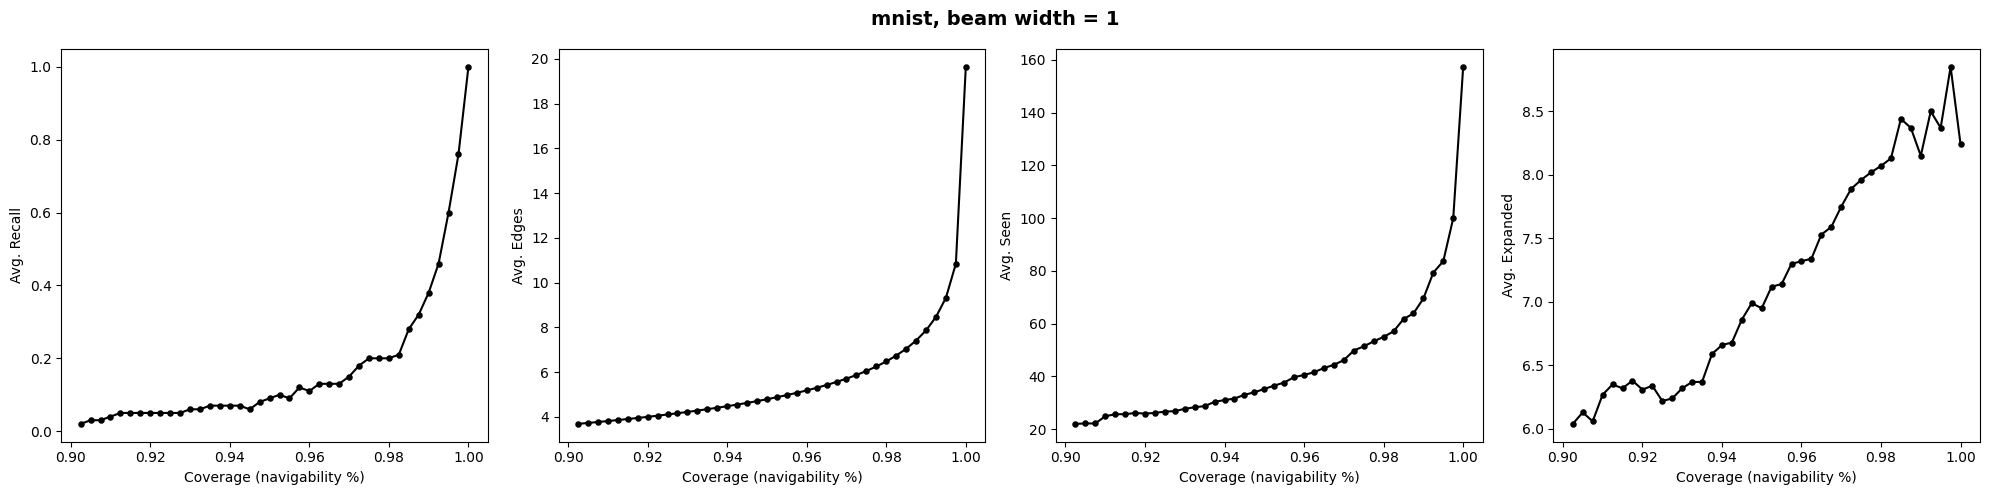

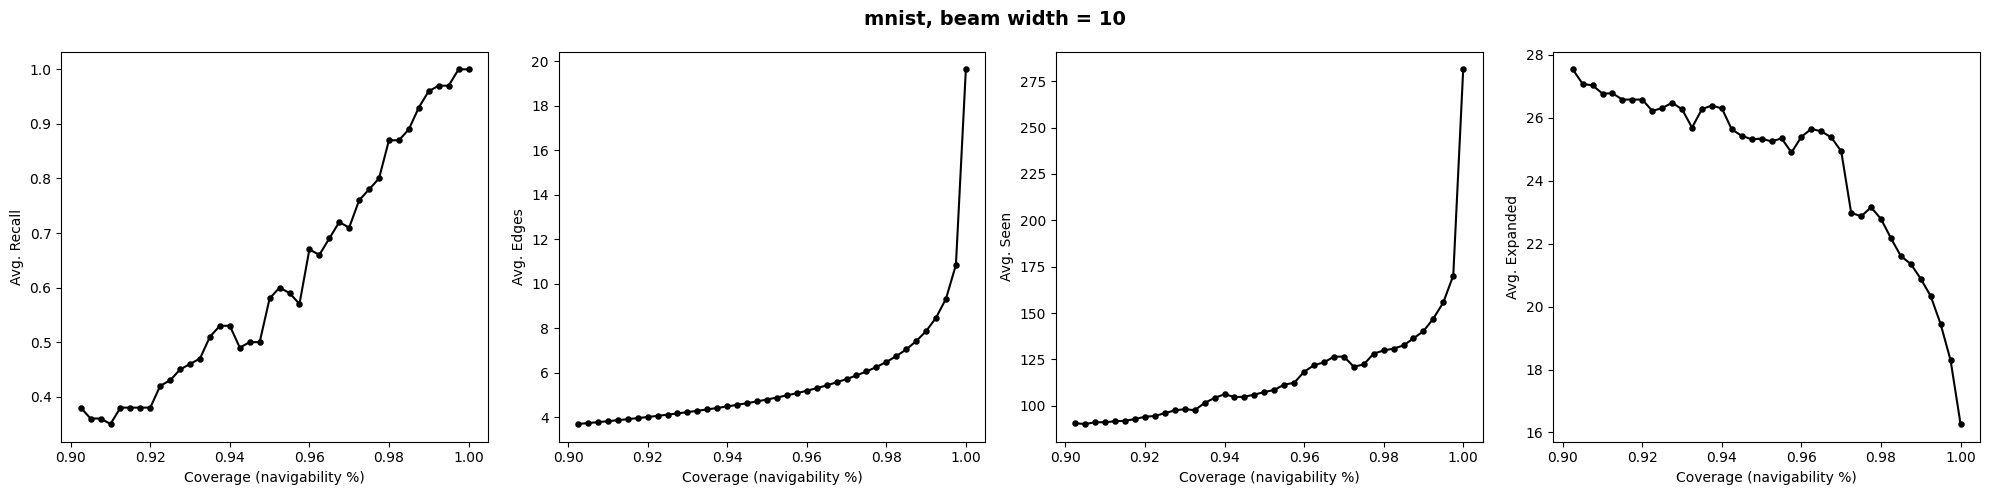

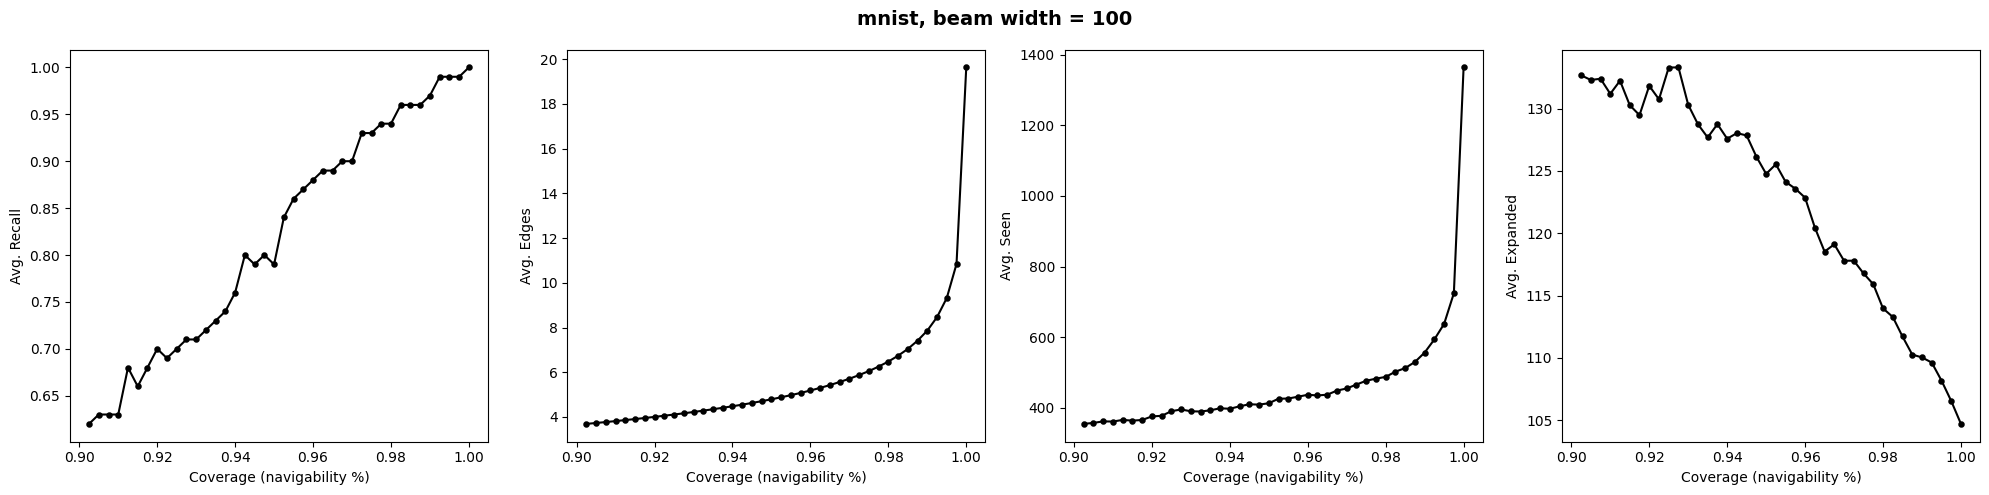

In [39]:
import re

plt.style.use('default')

TRAIN_COLOR = 'black'

for _, row in df.iterrows():
    coverages = sorted(
        [float(re.search(r'avg_edges_(.+)', c).group(1))
         for c in df.columns if c.startswith('avg_edges_')],
        reverse=True
    )

    avg_edges      = [row[f'avg_edges_{v}']      for v in coverages]
    train_recall   = [row[f'train_recall_{v}']   for v in coverages]
    train_seen     = [row[f'train_seen_{v}']     for v in coverages]
    train_expanded = [row[f'train_expanded_{v}'] for v in coverages]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{row['dataset']}, beam width = {row['beam_width']}", fontsize=14, fontweight='bold')

    plot_specs = [
        {'ylabel': 'Avg. Recall',   'train_y': train_recall},
        {'ylabel': 'Avg. Edges',    'train_y': avg_edges},
        {'ylabel': 'Avg. Seen',     'train_y': train_seen},
        {'ylabel': 'Avg. Expanded', 'train_y': train_expanded},
    ]

    for ax, spec in zip(axes, plot_specs):
        ax.plot(coverages, spec['train_y'], color=TRAIN_COLOR, linewidth=1.5)
        for xi, yi in zip(coverages, spec['train_y']):
            ax.scatter(xi, yi, color=TRAIN_COLOR, s=10, zorder=5, linewidths=1.5)
            # ax.text(xi, yi, f'{xi}', ha='center', va='center', fontsize=5, color=TRAIN_COLOR, zorder=3)
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(spec['ylabel'])

    plt.tight_layout()
    plt.show()


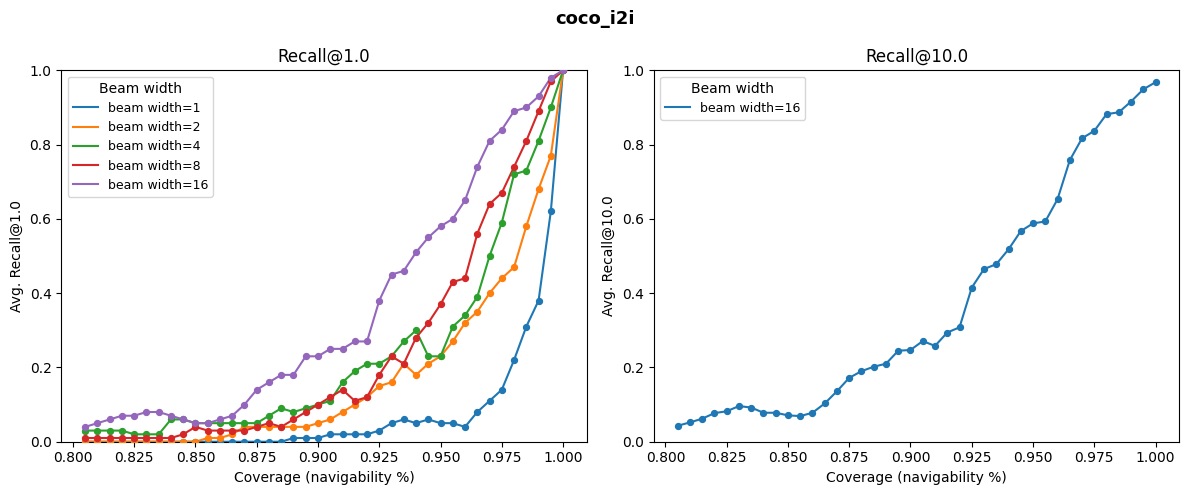

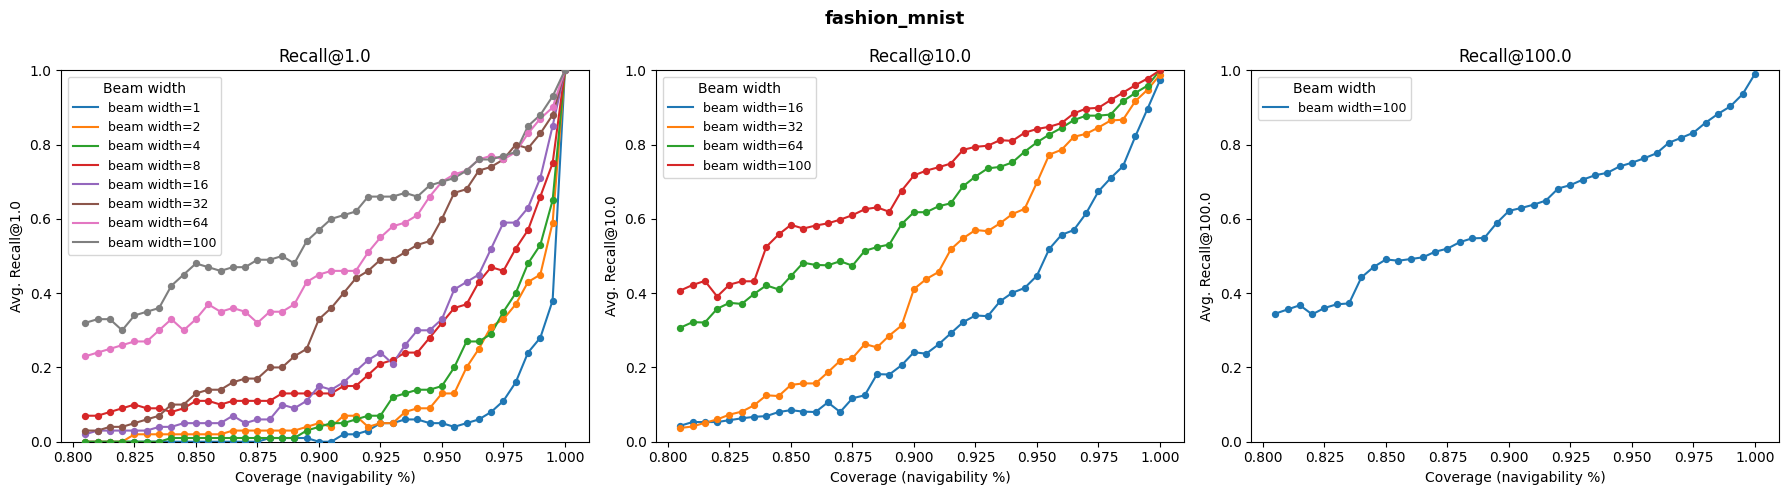

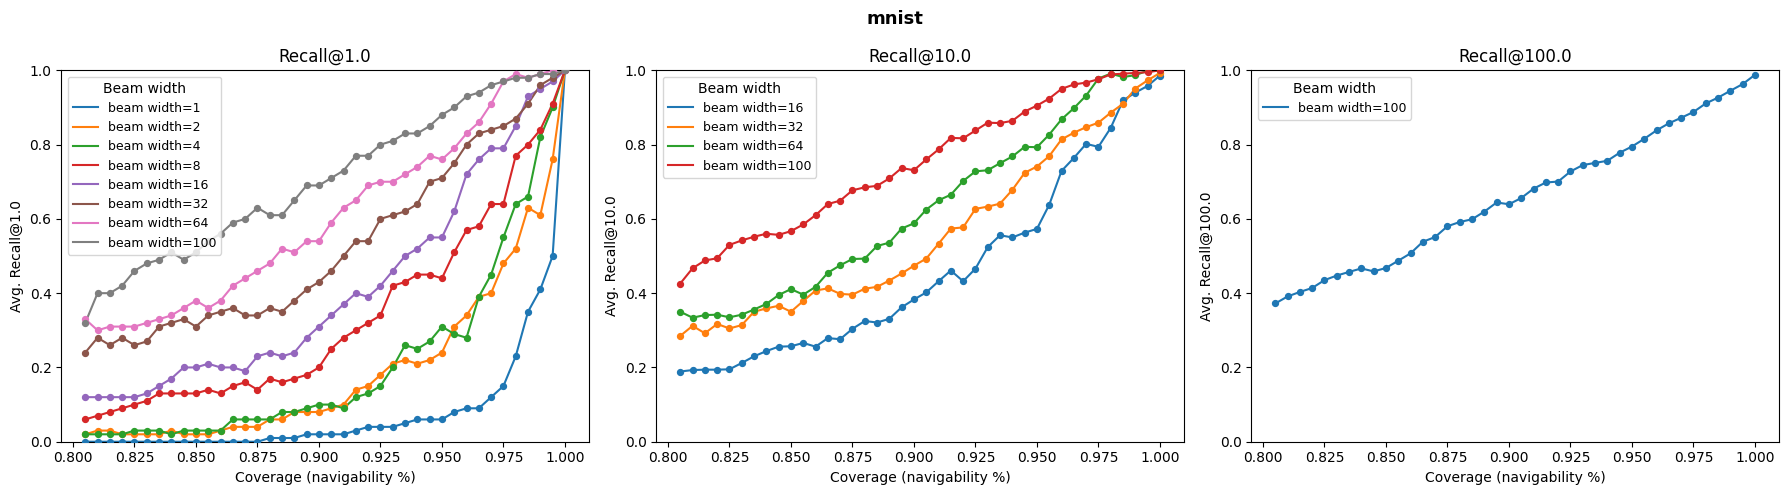

In [17]:
import re
import matplotlib.cm as cm

plt.style.use('default')

coverages = sorted(
    [float(re.search(r'avg_edges_(.+)', c).group(1))
     for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)

RECALL_KS = sorted(df['k'].unique())

for dataset, ds_df in df.groupby('dataset'):
    valid_ks = [k for k in RECALL_KS if not ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)].empty]
    if not valid_ks:
        continue

    fig, axes = plt.subplots(1, len(valid_ks), figsize=(6 * len(valid_ks), 5))
    if len(valid_ks) == 1:
        axes = [axes]
    fig.suptitle(dataset, fontsize=13, fontweight='bold')

    for ax, k in zip(axes, valid_ks):
        k_df = ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)]

        beam_widths = sorted(k_df['beam_width'].unique())
        colors      = cm.tab10.colors[:len(beam_widths)]
        color_map   = dict(zip(beam_widths, colors))

        for _, row in k_df.iterrows():
            bw    = row['beam_width']
            ys    = [row[f'train_recall_{v}'] for v in coverages]
            ax.plot(coverages, ys, color=color_map[bw], linewidth=1.5, label=f'beam width={bw}')
            ax.scatter(coverages, ys, color=color_map[bw], s=18, zorder=5)

        ax.set_title(f'Recall@{k}')
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(f'Avg. Recall@{k}')
        ax.set_ylim(0,1)
        ax.legend(title='Beam width', fontsize=9)

    plt.tight_layout()
    plt.show()